In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread("./../../CH03_Original_Images/Fig0354(a)(einstein_orig).tif")
print(f"Verificando shape: {img.shape}")

Verificando shape: (600, 490, 3)


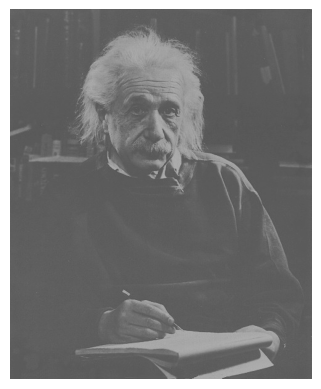

In [2]:
# Visualizando imagem em RGB

plt.imshow(img)
plt.axis("off")
plt.show()

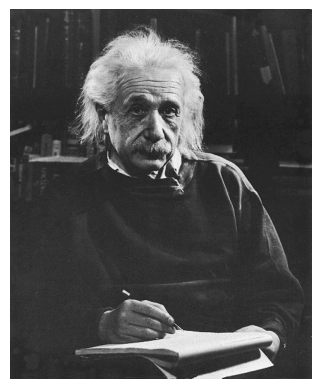

In [3]:
# Visualizando imagem em Escala de cinza

img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

plt.imshow(img_gray, cmap="gray")
plt.axis("off")
plt.show()

In [4]:
from typing import Literal
# Ampliação de pixels

def ampl_red_pixels(type_resize:Literal["reducao", "ampliacao"], img, factor:int=2):
    height, width = img.shape
    
    if type_resize == "ampliacao":
        new_img_gray = np.zeros((factor*height, factor*width))
        for h in range(height):
            for w in range(width):
                new_h = factor * h
                new_w = factor * w
                
                pixel_valor = img_gray[h, w]
                new_img_gray[new_h:new_h+factor, new_w:new_w+factor] = pixel_valor

    elif type_resize == "reducao":
        new_height, new_width = height // factor, width // factor
        new_img_gray = np.zeros((new_height, new_width), dtype=img.dtype)

        for h in range(new_height):
            for w in range(new_width):
                orig_h, orig_w = h * factor, w * factor
                new_img_gray[h, w] = img_gray[orig_h, orig_w]

    else:
        return img_gray
    
    return new_img_gray

Implementação usando numpy (muito mais otimizada, pois numpy é implementado em C/Fortran)

In [5]:
def ampl_red_pixels_numpy(type_resize:Literal["reducao", "ampliacao"], img:np.ndarray, factor:int=2):
    if type_resize == "ampliacao":
        new_img_gray = np.repeat(img, factor, axis=0) # replica a linhaa
        new_img_gray = np.repeat(new_img_gray, factor, axis=1) # replica a coluna
    elif type_resize == "reducao":
        new_img_gray = img_gray[::factor, ::factor]
    return new_img_gray

In [6]:
enlarged_image = ampl_red_pixels(type_resize="ampliacao", img=img_gray)

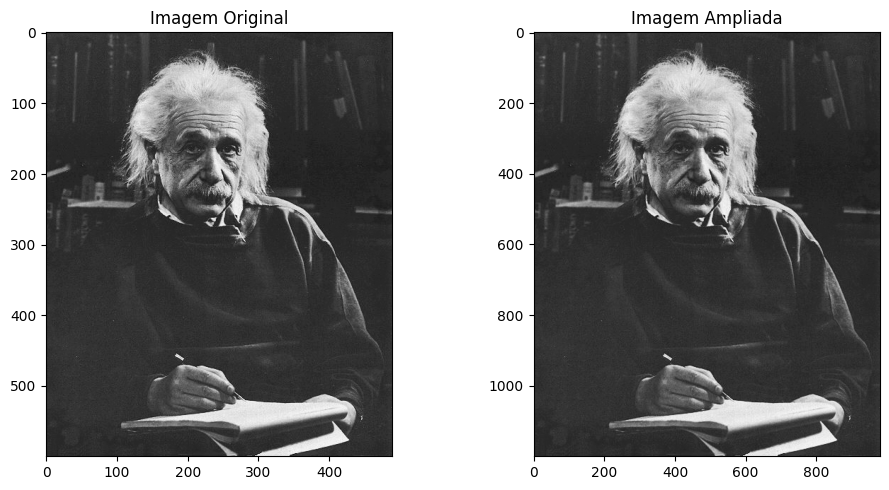

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))

axes[0].imshow(img_gray, cmap="gray")
axes[0].set_title('Imagem Original')


axes[1].imshow(enlarged_image, cmap="gray")
axes[1].set_title('Imagem Ampliada')

plt.tight_layout()
plt.show()

In [8]:
reduced_image = ampl_red_pixels("reducao", img=img_gray)

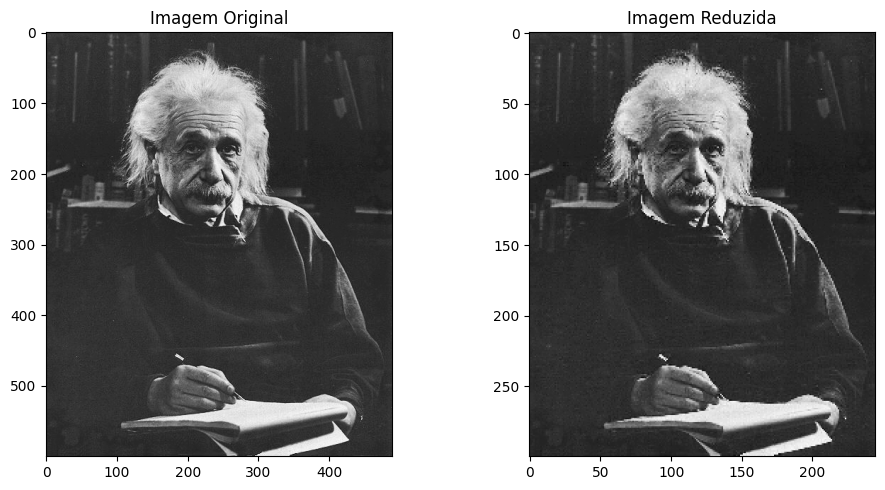

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))

axes[0].imshow(img_gray, cmap="gray")
axes[0].set_title('Imagem Original')


axes[1].imshow(reduced_image, cmap="gray")
axes[1].set_title('Imagem Reduzida')

plt.tight_layout()
plt.show()

b) usando fator de 10

In [10]:
enlarged_img_10 = ampl_red_pixels_numpy(type_resize="ampliacao", img=img_gray, factor=10)
reduced_img_10 = ampl_red_pixels_numpy(type_resize="reducao", img=img_gray, factor=10)

c) reampliando a imagem reduzida

In [11]:
enlarged_after_reduced = ampl_red_pixels_numpy(type_resize="ampliacao", img=reduced_img_10, factor=10)

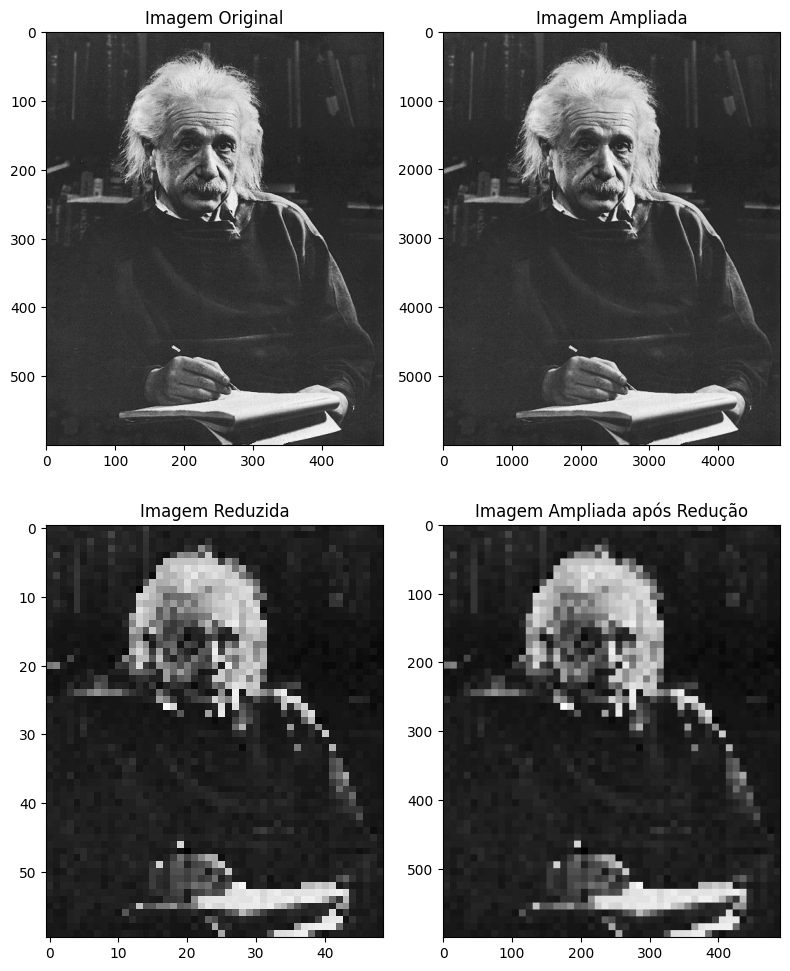

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(8,10))

axes[0,0].imshow(img_gray, cmap="gray")
axes[0,0].set_title('Imagem Original')


axes[0,1].imshow(enlarged_img_10, cmap="gray")
axes[0,1].set_title('Imagem Ampliada')

axes[1,0].imshow(reduced_img_10, cmap="gray")
axes[1,0].set_title('Imagem Reduzida')

axes[1,1].imshow(enlarged_after_reduced, cmap="gray")
axes[1,1].set_title('Imagem Ampliada após Redução')

plt.tight_layout()
plt.savefig("results/painel.png")
plt.show()